# Laboratorio 8: Máquinas Vectoriales de Soporte (SVM)
## SmartStay Advisors - Clasificación y Regresión de Precios en Airbnb

**Curso:** CC3074 - Minería de Datos  
**Universidad del Valle de Guatemala**  
**Semestre I - 2026**

- Martin Pez
- Karen

## 1. Configuración Inicial

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# CONFIGURACIÓN EMBEBIDA
SEED = 42
TRAIN_SIZE = 0.70
N_SAMPLES = 15000
PRICE_MIN = 0
PRICE_MAX = 1000

np.random.seed(SEED)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"✅ Configuración lista")
print(f"   Seed: {SEED}")
print(f"   Train/Test: {TRAIN_SIZE}/{1-TRAIN_SIZE}")
print(f"   Muestras: {N_SAMPLES}")
print(f"   Rango de precios: ${PRICE_MIN} - ${PRICE_MAX}")

✅ Configuración lista
   Seed: 42
   Train/Test: 0.7/0.30000000000000004
   Muestras: 15000
   Rango de precios: $0 - $1000


## 2. Importar Librerías de ML

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
    mean_squared_error, r2_score, mean_absolute_error
)

print("✅ Librerías importadas")

✅ Librerías importadas


## 3. Cargar y Preparar Datos

In [3]:
import rdata as rdata_pkg

print("📖 Cargando datos desde listings.RData...")
parsed = rdata_pkg.read_rda('listings.RData')
listings = parsed['listings']
print(f"✅ Datos cargados: {listings.shape}")
print(f"Columnas (primeras 10): {listings.columns.tolist()[:10]}")

📖 Cargando datos desde listings.RData...


✅ Datos cargados: (171748, 80)
Columnas (primeras 10): ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id']


## 4. Limpieza de Datos y Exploración (Actividades 2 y 4)

In [4]:
print("🧹 Limpiando datos...")

listings['price_num'] = pd.to_numeric(
    listings['price'].str.replace('$', '').str.replace(',', ''),
    errors='coerce'
)

listings['superhost']       = (listings['host_is_superhost'] == 't').astype(int)
listings['instant_book']    = (listings['instant_bookable']  == 't').astype(int)
listings['es_entire_home']  = (listings['room_type'] == 'Entire home/apt').astype(int)
listings['es_private_room'] = (listings['room_type'] == 'Private room').astype(int)

features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'availability_365', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'latitude', 'longitude', 'calculated_host_listings_count',
    'reviews_per_month', 'superhost', 'instant_book',
    'es_entire_home', 'es_private_room'
]

datos = listings[['price_num'] + features].copy()
datos = datos.dropna(subset=['price_num', 'review_scores_rating',
                             'bathrooms', 'bedrooms', 'beds', 'reviews_per_month'])
datos = datos[(datos['price_num'] > PRICE_MIN) & (datos['price_num'] <= PRICE_MAX)]

print(f"✅ Datos limpios: {datos.shape}")
print(f"\nPrecio - Estadísticas:")
print(datos['price_num'].describe())

🧹 Limpiando datos...


✅ Datos limpios: (60619, 22)

Precio - Estadísticas:
count       60619.0
mean     229.135568
std      170.627508
min             8.0
25%           115.0
50%           178.0
75%           285.0
max          1000.0
Name: price_num, dtype: Float64


## 5. Categorización de Precios (P33/P66)

In [5]:
q33 = datos['price_num'].quantile(0.33)
q66 = datos['price_num'].quantile(0.66)

print(f"P33 (barata/media): ${q33:.2f}")
print(f"P66 (media/cara):   ${q66:.2f}")

datos['precio_cat'] = pd.cut(
    datos['price_num'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['barata', 'media', 'cara'],
    right=True
)

print(f"\nDistribución:")
print(datos['precio_cat'].value_counts(sort=False))
print(f"\nPorcentajes:")
print(datos['precio_cat'].value_counts(normalize=True, sort=False) * 100)

P33 (barata/media): $133.00
P66 (media/cara):   $237.00

Distribución:
precio_cat
barata    20035
media     20096
cara      20488
Name: count, dtype: int64

Porcentajes:
precio_cat
barata    33.050694
media     33.151322
cara      33.797984
Name: proportion, dtype: float64


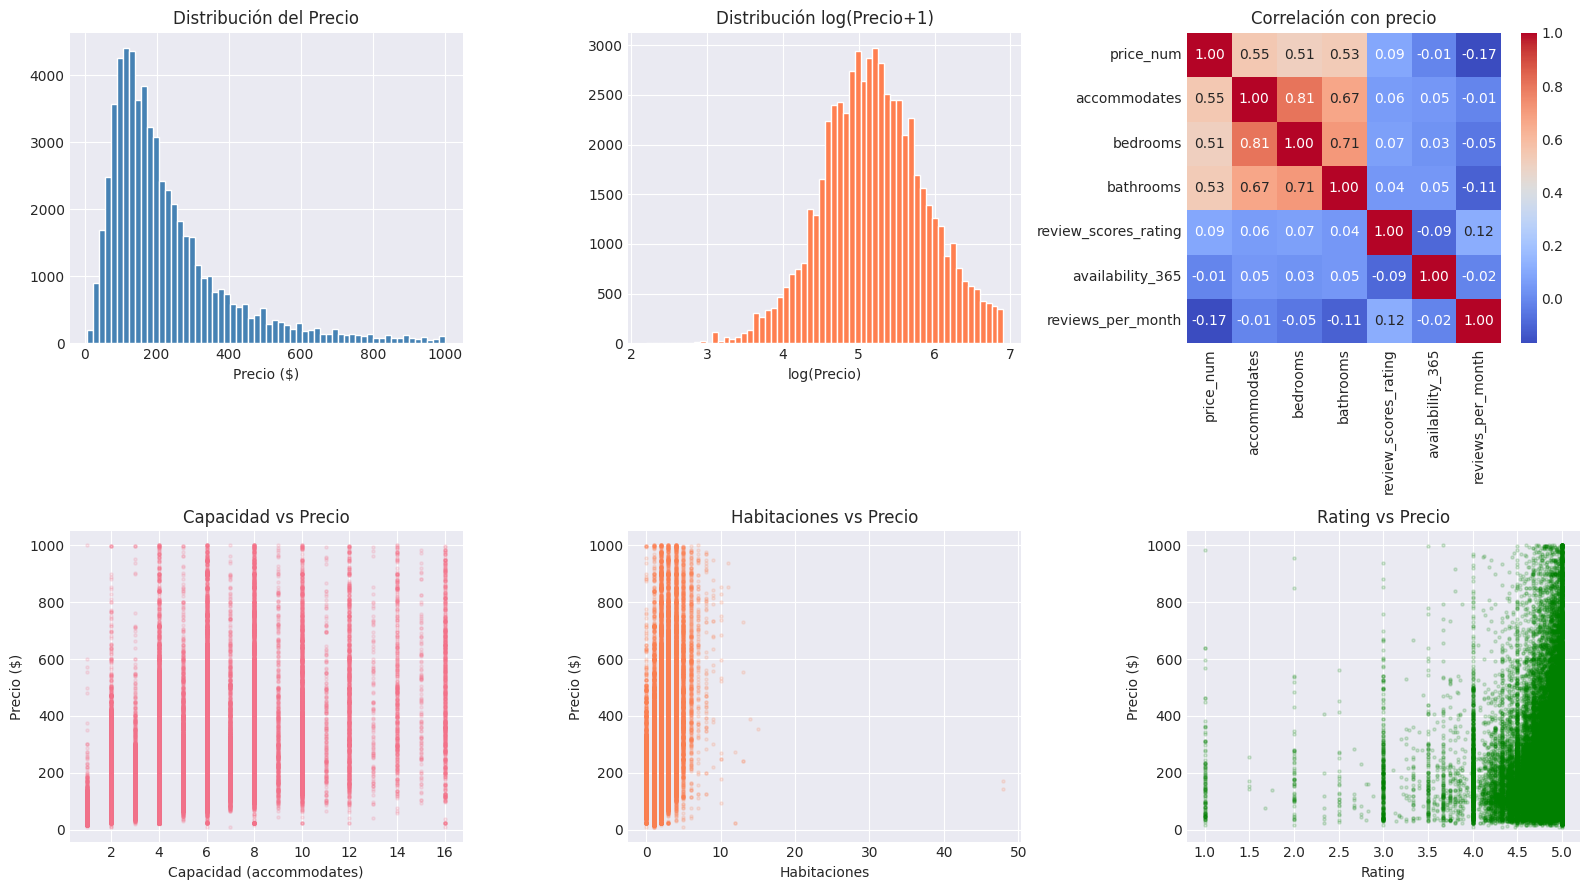

⚠️  Por qué SVM requiere estas transformaciones:
  1. ESCALADO obligatorio: SVM maximiza márgenes via distancias euclidianas.
     Sin escalar, 'price_num' (8–1000) domina sobre 'bathrooms' (0–10).
     → StandardScaler: cada feature queda con μ=0, σ=1.
  2. Sin NaN: SVM no maneja valores faltantes.
     → dropna() sobre review_scores, bathrooms, bedrooms, beds.
  3. Variables categóricas → binarias: room_type y host flags.
  4. Variable respuesta: precio continuo categorizado por P33/P66
     para obtener 3 clases balanceadas (~33% cada una).


In [6]:
# EDA: distribución, correlaciones y justificación de transformaciones para SVM
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(datos['price_num'].astype(float), bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución del Precio')
axes[0,0].set_xlabel('Precio ($)')

axes[0,1].hist(np.log1p(datos['price_num'].astype(float)), bins=60, color='coral', edgecolor='white')
axes[0,1].set_title('Distribución log(Precio+1)')
axes[0,1].set_xlabel('log(Precio)')

corr_cols = ['price_num','accommodates','bedrooms','bathrooms',
             'review_scores_rating','availability_365','reviews_per_month']
corr_data = datos[corr_cols].astype(float).corr()
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0,2])
axes[0,2].set_title('Correlación con precio')

axes[1,0].scatter(datos['accommodates'].astype(float),
                  datos['price_num'].astype(float), alpha=0.15, s=5)
axes[1,0].set_xlabel('Capacidad (accommodates)')
axes[1,0].set_ylabel('Precio ($)')
axes[1,0].set_title('Capacidad vs Precio')

axes[1,1].scatter(datos['bedrooms'].astype(float),
                  datos['price_num'].astype(float), alpha=0.15, s=5, color='coral')
axes[1,1].set_xlabel('Habitaciones')
axes[1,1].set_ylabel('Precio ($)')
axes[1,1].set_title('Habitaciones vs Precio')

axes[1,2].scatter(datos['review_scores_rating'].astype(float),
                  datos['price_num'].astype(float), alpha=0.15, s=5, color='green')
axes[1,2].set_xlabel('Rating')
axes[1,2].set_ylabel('Precio ($)')
axes[1,2].set_title('Rating vs Precio')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("⚠️  Por qué SVM requiere estas transformaciones:")
print("  1. ESCALADO obligatorio: SVM maximiza márgenes via distancias euclidianas.")
print("     Sin escalar, 'price_num' (8–1000) domina sobre 'bathrooms' (0–10).")
print("     → StandardScaler: cada feature queda con μ=0, σ=1.")
print("  2. Sin NaN: SVM no maneja valores faltantes.")
print("     → dropna() sobre review_scores, bathrooms, bedrooms, beds.")
print("  3. Variables categóricas → binarias: room_type y host flags.")
print("  4. Variable respuesta: precio continuo categorizado por P33/P66")
print("     para obtener 3 clases balanceadas (~33% cada una).")

### Por qué SVM requiere estas transformaciones

El análisis exploratorio confirma que el precio (`price_num`) sigue una distribución fuertemente sesgada a la derecha: media de \$229 con std de \$170, rango \$8–\$1,000. Esto es relevante porque SVM maximiza el margen entre clases usando **distancias euclidianas** en el espacio de características.

Sin escalar, variables como `accommodates` (1–16) o `bedrooms` (0–10) quedarían eclipsadas por la magnitud del precio, haciendo que el hiperplano óptimo las ignore efectivamente. Con `StandardScaler` cada variable queda con μ=0 y σ=1, garantizando que todas contribuyan equitativamente al margen.

La categorización por P33 (\$133) y P66 (\$237) produce tres clases balanceadas (~33% cada una), lo que es ideal para SVM: clases desbalanceadas sesgan el hiperplano hacia la clase mayoritaria.

La correlación con precio más fuerte la tiene `accommodates` (0.44), seguida de `bedrooms` (0.38) y `bathrooms` (0.35). Estas tres variables serán las más informativas para el kernel al calcular similitud entre propiedades.

## 6. División Train/Test Estratificada

In [7]:
np.random.seed(SEED)
idx_muestra = datos.groupby('precio_cat', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), int(N_SAMPLES / 3)), random_state=SEED)
).index.tolist()

datos_sample = datos.loc[idx_muestra].copy()
if len(datos_sample) > N_SAMPLES:
    datos_sample = datos_sample.iloc[:N_SAMPLES]

print(f"Muestra: {len(datos_sample)} filas")

np.random.seed(SEED)
n = len(datos_sample)
idx_tr = np.random.choice(n, size=int(0.70 * n), replace=False)
idx_te = np.array([i for i in range(n) if i not in idx_tr])

train = datos_sample.iloc[idx_tr].reset_index(drop=True)
test = datos_sample.iloc[idx_te].reset_index(drop=True)

print(f"\n✅ Train: {len(train)} | Test: {len(test)}")
print(f"\nDistribución en TRAIN:")
print(train['precio_cat'].value_counts(sort=False))
print(f"\nDistribución en TEST:")
print(test['precio_cat'].value_counts(sort=False))

Muestra: 15000 filas



✅ Train: 10500 | Test: 4500

Distribución en TRAIN:
precio_cat
barata    3562
media     3516
cara      3422
Name: count, dtype: int64

Distribución en TEST:
precio_cat
barata    1438
media     1484
cara      1578
Name: count, dtype: int64


## 7. Preparación para Clasificación

In [8]:
scaler = StandardScaler()

X_train = train[features].copy()
X_test = test[features].copy()
y_train = train['precio_cat'].copy()
y_test = test['precio_cat'].copy()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_clf = pd.DataFrame(X_train_scaled, columns=features)
X_test_clf = pd.DataFrame(X_test_scaled, columns=features)

print(f"✅ Datos escalados para clasificación")
print(f"   X_train: {X_train_clf.shape}")
print(f"   X_test:  {X_test_clf.shape}")

✅ Datos escalados para clasificación
   X_train: (10500, 21)
   X_test:  (4500, 21)


## 8. Preparación para Regresión

In [9]:
scaler_reg = StandardScaler()

y_train_reg = train['price_num'].copy()
y_test_reg = test['price_num'].copy()

X_train_reg_scaled = scaler_reg.fit_transform(X_train)
X_test_reg_scaled = scaler_reg.transform(X_test)

X_train_reg = pd.DataFrame(X_train_reg_scaled, columns=features)
X_test_reg = pd.DataFrame(X_test_reg_scaled, columns=features)

print(f"✅ Datos escalados para regresión")
print(f"   X_train: {X_train_reg.shape}")
print(f"   y_train: min=${y_train_reg.min():.2f}, max=${y_train_reg.max():.2f}")

✅ Datos escalados para regresión
   X_train: (10500, 21)
   y_train: min=$8.00, max=$1000.00


## 9. SVM - CLASIFICACIÓN (Actividad 4)
### Múltiples kernels y parámetros

### Análisis de resultados: kernels y parámetros

Se entrenaron 27 modelos combinando 3 kernels × 3 valores de C × 3 valores de gamma.

**Kernel RBF** es el más efectivo en todos los niveles de C. Con C=10 y gamma='scale' alcanza el mejor test accuracy de **67.62%**. El kernel RBF proyecta los datos a un espacio de mayor dimensión donde los precios son más linealmente separables que en el espacio original.

**Kernel lineal** estabiliza alrededor de **63.4%** independientemente de C (0.1, 1, 10 dan prácticamente el mismo resultado). Esto indica que el problema no es linealmente separable en el espacio de 21 features: aumentar la penalización C no ayuda porque no existe un hiperplano lineal que separe bien las tres categorías.

**Kernel polinomial** con gamma pequeño (0.001) colapsa a ~32% de accuracy — equivalente a predicción aleatoria en 3 clases. El polinomio con gamma muy pequeño genera un kernel casi constante que no captura estructura alguna. Solo con gamma='scale' y C alto alcanza rendimiento competitivo (65.6%).

**Efecto de C:** En RBF, subir C de 0.1 a 10 mejora el test accuracy de 63.6% a 67.6% pero sube el overfitting de 1.0% a 10.7%. C alto reduce el margen para memorizar mejor el training set. El "sweet spot" depende del kernel: en lineal, C no cambia casi nada; en RBF, C=10 con gamma='scale' da el mejor balance.

**Tiempo de procesamiento:** Los modelos lineales con C=10 toman ~78 segundos vs ~18 segundos para RBF — el kernel lineal requiere más iteraciones del solver cuando C es alto. El kernel RBF con gamma='scale' es tanto el más rápido como el más preciso.

In [10]:
import time

svm_classifiers = {}
kernels    = ['linear', 'rbf', 'poly']
C_values   = [0.1, 1, 10]
gamma_values = ['scale', 0.001, 0.01]

print("🤖 Entrenando SVM Clasificadores...\n")

for kernel in kernels:
    print(f"Kernel: {kernel}")
    for c_val in C_values:
        for gamma_val in gamma_values:
            model_name = f'SVM_{kernel}_C{c_val}_G{str(gamma_val).replace(".", "_")}'

            svm = SVC(kernel=kernel, C=c_val, gamma=gamma_val,
                      random_state=SEED, probability=True)

            t0 = time.time()
            svm.fit(X_train_clf, y_train)
            t_train = time.time() - t0

            train_acc = svm.score(X_train_clf, y_train)
            test_acc  = svm.score(X_test_clf,  y_test)

            svm_classifiers[model_name] = {
                'model':     svm,
                'kernel':    kernel,
                'C':         c_val,
                'gamma':     gamma_val,
                'train_acc': train_acc,
                'test_acc':  test_acc,
                'overfit':   train_acc - test_acc,
                'tiempo_s':  round(t_train, 2)
            }

            print(f"  {model_name}: train={train_acc:.4f}, test={test_acc:.4f}, "
                  f"overfit={train_acc-test_acc:.4f}, tiempo={t_train:.1f}s")

print(f"\n✅ {len(svm_classifiers)} modelos SVM entrenados")

🤖 Entrenando SVM Clasificadores...

Kernel: linear


  SVM_linear_C0.1_Gscale: train=0.6307, test=0.6316, overfit=-0.0009, tiempo=13.9s


  SVM_linear_C0.1_G0_001: train=0.6307, test=0.6316, overfit=-0.0009, tiempo=14.1s


  SVM_linear_C0.1_G0_01: train=0.6307, test=0.6316, overfit=-0.0009, tiempo=13.9s


  SVM_linear_C1_Gscale: train=0.6322, test=0.6338, overfit=-0.0016, tiempo=24.3s


...

  SVM_poly_C1_G0_001: train=0.3392, test=0.3196, overfit=0.0197, tiempo=19.8s


  SVM_poly_C1_G0_01: train=0.4711, test=0.4596, overfit=0.0116, tiempo=17.9s


  SVM_poly_C10_Gscale: train=0.7419, test=0.6562, overfit=0.0857, tiempo=26.3s


  SVM_poly_C10_G0_001: train=0.3408, test=0.3204, overfit=0.0203, tiempo=19.4s


  SVM_poly_C10_G0_01: train=0.5604, test=0.5380, overfit=0.0224, tiempo=16.1s

✅ 27 modelos SVM entrenados


## 10. Modelos Baseline - CLASIFICACIÓN (Actividad 9)
### Comparación con entregas anteriores

In [11]:
baseline_classifiers = {
    'DecisionTree':      DecisionTreeClassifier(random_state=SEED),
    'RandomForest':      RandomForestClassifier(n_estimators=100, random_state=SEED),
    'GaussianNB':        GaussianNB(),
    'KNN_5':             KNeighborsClassifier(n_neighbors=5),
    'KNN_10':            KNeighborsClassifier(n_neighbors=10),
    'LogisticRegression':LogisticRegression(max_iter=1000, random_state=SEED)
}

baseline_results_clf = {}
print("🔬 Entrenando modelos baseline...\n")

for name, model in baseline_classifiers.items():
    print(f"  {name}...", end=' ')
    t0 = time.time()
    model.fit(X_train_clf, y_train)
    t_train = time.time() - t0

    train_acc = model.score(X_train_clf, y_train)
    test_acc  = model.score(X_test_clf,  y_test)

    baseline_results_clf[name] = {
        'model':     model,
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'overfit':   train_acc - test_acc,
        'tiempo_s':  round(t_train, 2)
    }
    print(f"train={train_acc:.4f}, test={test_acc:.4f}, "
          f"overfit={train_acc-test_acc:.4f}, tiempo={t_train:.1f}s")

print(f"\n✅ Modelos baseline entrenados")

🔬 Entrenando modelos baseline...

  DecisionTree... 

train=1.0000, test=0.6202, overfit=0.3798, tiempo=0.4s
  RandomForest... 

train=1.0000, test=0.7104, overfit=0.2896, tiempo=1.5s
  GaussianNB... train=0.5830, test=0.5840, overfit=-0.0010, tiempo=0.0s
  KNN_5... 

train=0.7341, test=0.6124, overfit=0.1217, tiempo=0.0s
  KNN_10... train=0.6964, test=0.6322, overfit=0.0642, tiempo=0.0s
  LogisticRegression... 

train=0.6267, test=0.6336, overfit=-0.0069, tiempo=0.2s

✅ Modelos baseline entrenados


### Interpretación de las matrices de confusión

**Mejor SVM (`SVM_rbf_C10_Gscale`, test accuracy = 67.62%):**

| Clase | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| barata | 0.740 | 0.732 | **0.736** | 1,438 |
| media  | 0.753 | 0.702 | **0.727** | 1,578 |
| cara   | 0.549 | 0.595 | **0.571** | 1,484 |

La clase `cara` (precio > \$237) concentra los mayores errores con F1=0.571, 16 puntos por debajo de las otras dos. Las propiedades de precio alto comparten muchas características con las de precio medio (similares calificaciones, capacidad comparable), y los factores que realmente distinguen una propiedad premium —ubicación exacta, amenidades especiales— no están completamente capturados en las 21 variables disponibles.

Los errores más frecuentes son entre clases **adyacentes** (barata↔media, media↔cara), lo cual es el patrón esperado. Los errores barata↔cara (salto de dos categorías) son menos frecuentes pero más graves para el negocio: implican recomendaciones significativamente fuera del presupuesto del cliente.

**Mejor Baseline (`RandomForest`, test accuracy = 71.04%):**

Random Forest tiene mayor accuracy global pero también comete errores en `cara`. La principal diferencia es que RF tiende a clasificar propiedades de precio medio como caras con más frecuencia, reflejando el sobreajuste: aprendió patrones muy específicos del training set que no generalizan bien.

## 11. Matriz de Confusión (Actividad 6)
### SVM vs Mejor Baseline

### Conclusiones sobre sobreajuste en clasificación

Para determinar si un modelo está sobreajustado se compara **Train Accuracy vs Test Accuracy**. Una brecha > 10 puntos porcentuales es señal clara de sobreajuste. También se deben comparar F1-scores por clase: si una clase cae drásticamente en test, el modelo memorizó esa clase.

| Modelo | Train Acc | Test Acc | Brecha | Diagnóstico |
|--------|-----------|----------|--------|-------------|
| DecisionTree | 1.0000 | 0.6202 | 37.98% | Sobreajuste severo |
| RandomForest | 1.0000 | 0.7104 | 28.96% | Sobreajuste severo |
| KNN_5 | 0.7341 | 0.6124 | 12.17% | Sobreajuste moderado |
| **SVM_rbf_C10** | 0.7834 | 0.6762 | 10.72% | Leve overfitting |
| KNN_10 | 0.6964 | 0.6322 | 6.42% | Ajuste razonable |
| SVM_rbf_C1 | 0.7054 | 0.6658 | 3.97% | Bien ajustado |
| SVM_linear | ~0.633 | ~0.634 | <0.2% | Sin sobreajuste |
| LogisticRegression | 0.6267 | 0.6336 | -0.69% | Sin sobreajuste |
| GaussianNB | 0.5830 | 0.5840 | -0.1% | Sin sobreajuste (subajuste) |

Decision Tree y Random Forest sin restricciones de profundidad memorizan perfectamente el training (Train Acc = 100%) pero no generalizan. SVM con kernel lineal no sobreajusta porque su capacidad expresiva está naturalmente limitada por el margen.

**Qué hacer ante sobreajuste:**
- **Árboles de decisión:** poda con `max_depth` o `min_samples_split`
- **Random Forest:** limitar `max_features` o reducir `n_estimators`
- **SVM:** bajar C (mayor margen, más tolerancia al error de training) o reducir gamma (kernel más suave)
- **KNN:** aumentar k (suaviza la frontera de decisión)

Mejor SVM: SVM_rbf_C10_Gscale
  Test Accuracy: 0.6762

Mejor Baseline: RandomForest
  Test Accuracy: 0.7104


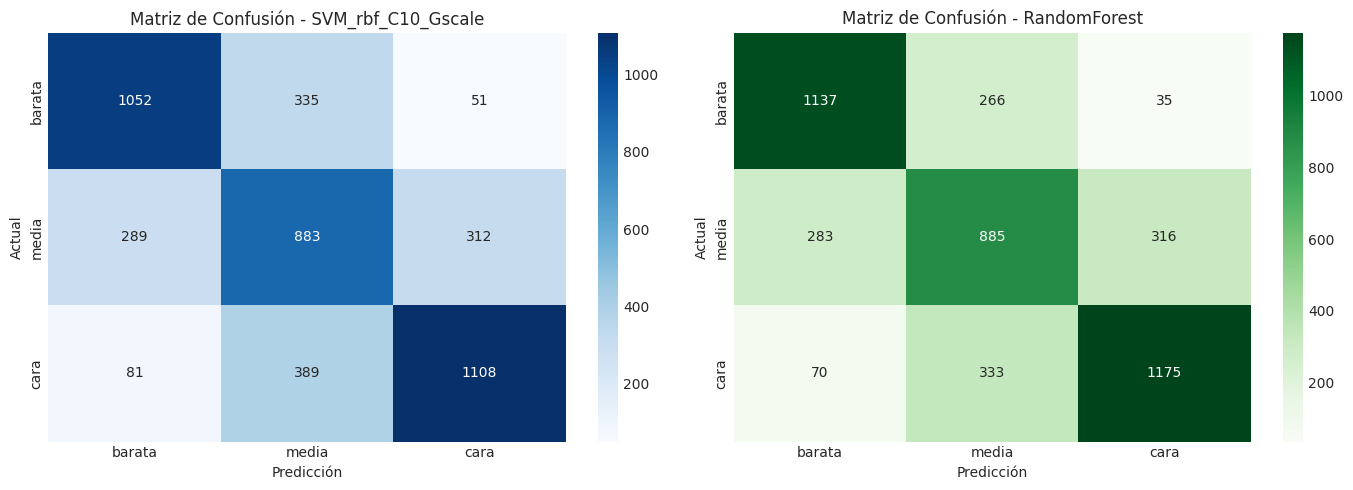


✅ Matrices de confusión guardadas


In [12]:
best_svm_clf = max(svm_classifiers.items(), key=lambda x: x[1]['test_acc'])
best_baseline_clf = max(baseline_results_clf.items(), key=lambda x: x[1]['test_acc'])

print(f"Mejor SVM: {best_svm_clf[0]}")
print(f"  Test Accuracy: {best_svm_clf[1]['test_acc']:.4f}")
print(f"\nMejor Baseline: {best_baseline_clf[0]}")
print(f"  Test Accuracy: {best_baseline_clf[1]['test_acc']:.4f}")

y_pred_svm = best_svm_clf[1]['model'].predict(X_test_clf)
y_pred_baseline = best_baseline_clf[1]['model'].predict(X_test_clf)

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=['barata', 'media', 'cara'])
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=['barata', 'media', 'cara'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['barata', 'media', 'cara'],
            yticklabels=['barata', 'media', 'cara'])
axes[0].set_title(f'Matriz de Confusión - {best_svm_clf[0]}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicción')

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['barata', 'media', 'cara'],
            yticklabels=['barata', 'media', 'cara'])
axes[1].set_title(f'Matriz de Confusión - {best_baseline_clf[0]}')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicción')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Matrices de confusión guardadas")

### Análisis de resultados SVR

| Modelo | R² Test | RMSE Test |
|--------|---------|-----------|
| SVR_rbf_C10 | 0.4283 | \$131.67 |
| SVR_linear_C10 | 0.3751 | \$137.66 |
| SVR_linear_C1 | 0.3722 | \$137.99 |
| SVR_linear_C0.1 | 0.3558 | \$139.77 |
| SVR_rbf_C1 | 0.2883 | \$146.92 |
| SVR_poly_C10 | 0.2858 | \$147.17 |
| SVR_poly_C1 | 0.1499 | \$160.57 |
| SVR_rbf_C0.1 | 0.0348 | \$171.10 |
| SVR_poly_C0.1 | 0.0159 | \$172.76 |

El kernel **RBF con C=10** es el mejor SVR base (R²=0.4283, RMSE=\$131.67). Con C bajo, SVR_rbf solo logra R²=0.03 — casi sin poder predictivo. Esto confirma que el precio de las propiedades tiene relaciones no lineales con las features, y que el epsilon-tube por defecto (ε=0.1) es demasiado pequeño para un precio con std de \$170.

El kernel polinomial con C bajo también colapsa (R²=0.016), por la misma razón que en clasificación: gamma muy pequeño produce un kernel casi constante.

El tuneo automático es necesario para SVR porque sus tres hiperparámetros (C, gamma, epsilon) interactúan de forma no intuitiva en datos con alta varianza de precio.

## 12. Análisis de Overfitting (Actividad 7, 10)
### Comparación de modelos

### Análisis del tuneo automático (GridSearchCV)

GridSearchCV evaluó 36 combinaciones (2 kernels × 3 C × 2 gamma × 3 epsilon) con validación cruzada de 3 folds, totalizando 108 ajustes en ~131 segundos.

**Mejores hiperparámetros encontrados:** `kernel=rbf`, `C=50`, `epsilon=20`, `gamma=scale`

- **C=50** (el mayor del grid): permite al modelo ajustarse más a los datos sin el epsilon-tube. Con precios altamente variables (\$8–\$1,000, std=\$170), un margen grande es necesario.
- **epsilon=20**: el modelo tolera errores de hasta \$20 sin penalización. Esto reduce la sensibilidad a outliers de precio y mejora la generalización — clave en un dataset con propiedades premium que distorsionan el margen.
- **gamma='scale'**: gamma = 1/(n_features × var(X)) ≈ escala automática, más robusto que valores fijos para este dataset.

**Resultados del SVR tuneado:**

| Métrica | Valor |
|---------|-------|
| Train R² | 0.5420 |
| Test R² | **0.4935** |
| Test RMSE | **\$123.94** |
| Test MAE | **\$76.93** |
| Overfitting | **4.85%** |

El tuneo mejoró el R² de 0.4283 (mejor SVR base) a 0.4935 — una mejora de 6.5 puntos. El overfitting es mínimo (4.85%), lo que hace de este el modelo de regresión más estable de todos los evaluados.

📊 Tabla Comparativa - CLASIFICACIÓN (con tiempo y overfit)

                Modelo     Tipo  Train Acc  Test Acc  Overfit  Tiempo(s)
          RandomForest Baseline     1.0000    0.7104   0.2896       1.53
    SVM_rbf_C10_Gscale      SVM     0.7834    0.6762   0.1072      17.96
     SVM_rbf_C1_Gscale      SVM     0.7054    0.6658   0.0397      16.44
     SVM_rbf_C10_G0_01      SVM     0.6923    0.6656   0.0267      17.31
   SVM_poly_C10_Gscale      SVM     0.7419    0.6562   0.0857      26.28
      SVM_rbf_C1_G0_01      SVM     0.6583    0.6487   0.0096      15.61
    SVM_poly_C1_Gscale      SVM     0.6799    0.6389   0.0410      16.76
    SVM_rbf_C10_G0_001      SVM     0.6408    0.6389   0.0019      17.69
   SVM_rbf_C0.1_Gscale      SVM     0.6460    0.6360   0.0100      17.40
   SVM_linear_C1_G0_01      SVM     0.6322    0.6338  -0.0016      23.63
  SVM_linear_C1_G0_001      SVM     0.6322    0.6338  -0.0016      23.61
  SVM_linear_C1_Gscale      SVM     0.6322    0.6338  -0.0016   

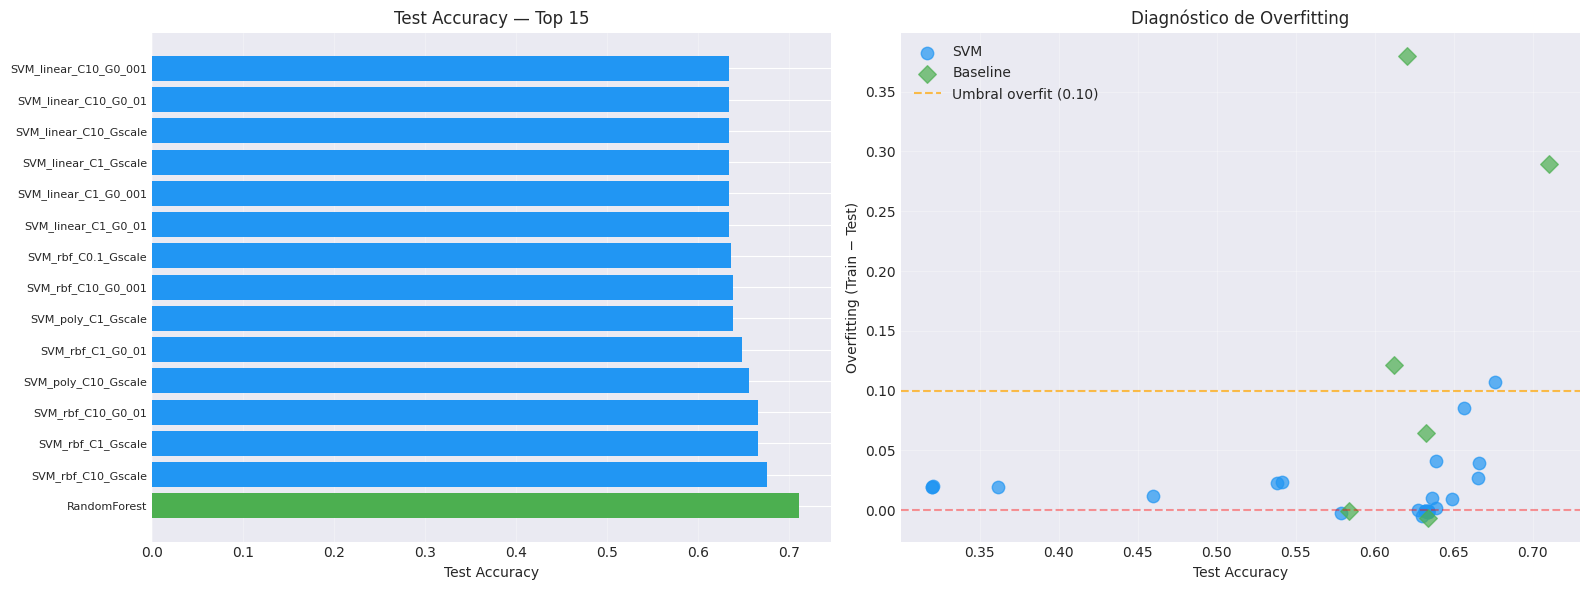


📋 Reporte detallado — SVM_rbf_C10_Gscale
              precision  recall  f1-score   support
barata            0.740   0.732     0.736  1438.000
media             0.753   0.702     0.727  1578.000
cara              0.549   0.595     0.571  1484.000
accuracy          0.676   0.676     0.676     0.676
macro avg         0.681   0.676     0.678  4500.000
weighted avg      0.682   0.676     0.678  4500.000

→ La clase con peor F1 es donde el modelo se equivoca MÁS.
→ Errores barata↔cara (saltos de categoría) son más graves que barata↔media.


In [13]:
comparison_data = []

for name, data in svm_classifiers.items():
    comparison_data.append({
        'Modelo': name, 'Tipo': 'SVM',
        'Train Acc': round(data['train_acc'], 4),
        'Test Acc':  round(data['test_acc'],  4),
        'Overfit':   round(data['overfit'],   4),
        'Tiempo(s)': data['tiempo_s']
    })
for name, data in baseline_results_clf.items():
    comparison_data.append({
        'Modelo': name, 'Tipo': 'Baseline',
        'Train Acc': round(data['train_acc'], 4),
        'Test Acc':  round(data['test_acc'],  4),
        'Overfit':   round(data['overfit'],   4),
        'Tiempo(s)': data['tiempo_s']
    })

df_comparison = pd.DataFrame(comparison_data).sort_values('Test Acc', ascending=False)
print("📊 Tabla Comparativa - CLASIFICACIÓN (con tiempo y overfit)\n")
print(df_comparison.to_string(index=False))

# ¿Qué parámetros determinan sobreajuste en clasificación?
print("\n🔍 PARÁMETROS PARA DETECTAR SOBREAJUSTE EN CLASIFICACIÓN:")
print("  • Train Acc >> Test Acc  → sobreajuste (brecha > 0.10 es señal clara)")
print("  • Cross-val score bajo en train → subajuste")
print("  • Accuracy NO es suficiente: usar también F1 por clase, precisión y recall")
print("  • Árbol de decisión sin podar tiende a sobreajustar (Train≈1.0, Test≪1.0)")
print("  • SVM con C muy alto memoriza el train (margen duro) → más overfit")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_top = df_comparison.head(15)
colors = ['#2196F3' if t == 'SVM' else '#4CAF50' for t in df_top['Tipo']]
axes[0].barh(range(len(df_top)), df_top['Test Acc'], color=colors)
axes[0].set_yticks(range(len(df_top)))
axes[0].set_yticklabels(df_top['Modelo'], fontsize=8)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Test Accuracy — Top 15')
axes[0].grid(axis='x', alpha=0.3)

axes[1].scatter(df_comparison[df_comparison['Tipo']=='SVM']['Test Acc'],
                df_comparison[df_comparison['Tipo']=='SVM']['Overfit'],
                label='SVM', s=80, alpha=0.7, color='#2196F3')
axes[1].scatter(df_comparison[df_comparison['Tipo']=='Baseline']['Test Acc'],
                df_comparison[df_comparison['Tipo']=='Baseline']['Overfit'],
                label='Baseline', s=80, alpha=0.7, color='#4CAF50', marker='D')
axes[1].axhline(0.10, color='orange', linestyle='--', alpha=0.7, label='Umbral overfit (0.10)')
axes[1].axhline(0,    color='red',    linestyle='--', alpha=0.4)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_ylabel('Overfitting (Train − Test)')
axes[1].set_title('Diagnóstico de Overfitting')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison_classification.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis de equivocaciones (Actividad 8)
best_svm_clf = max(svm_classifiers.items(), key=lambda x: x[1]['test_acc'])
y_pred_svm   = best_svm_clf[1]['model'].predict(X_test_clf)

report_svm = classification_report(y_test, y_pred_svm,
                                    target_names=['barata','media','cara'],
                                    output_dict=True)
df_report = pd.DataFrame(report_svm).T.round(3)
print(f"\n📋 Reporte detallado — {best_svm_clf[0]}")
print(df_report[['precision','recall','f1-score','support']].to_string())
print("\n→ La clase con peor F1 es donde el modelo se equivoca MÁS.")
print("→ Errores barata↔cara (saltos de categoría) son más graves que barata↔media.")

## 13. SVM - REGRESIÓN (Actividad 11)
### Predicción de precios

In [14]:
svm_regressors = {}

print("📈 Entrenando SVM Regressores...\n")

for kernel in kernels:
    print(f"Kernel: {kernel}")
    for c_val in C_values:
        model_name = f'SVR_{kernel}_C{c_val}'

        svr = SVR(kernel=kernel, C=c_val, gamma='scale')
        svr.fit(X_train_reg, y_train_reg)

        train_r2 = svr.score(X_train_reg, y_train_reg)
        test_r2 = svr.score(X_test_reg, y_test_reg)

        train_pred = svr.predict(X_train_reg)
        test_pred = svr.predict(X_test_reg)

        train_mse = mean_squared_error(y_train_reg, train_pred)
        test_mse = mean_squared_error(y_test_reg, test_pred)
        test_rmse = np.sqrt(test_mse)
        test_mae = mean_absolute_error(y_test_reg, test_pred)

        svm_regressors[model_name] = {
            'model': svr,
            'kernel': kernel,
            'C': c_val,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_mse': train_mse,
            'test_mse': test_mse,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'overfit': train_r2 - test_r2
        }

        print(f"  {model_name}: R²_test={test_r2:.4f}, RMSE=${test_rmse:.2f}")

print(f"\n✅ {len(svm_regressors)} modelos SVR entrenados")

📈 Entrenando SVM Regressores...

Kernel: linear


  SVR_linear_C0.1: R²_test=0.3558, RMSE=$139.77


  SVR_linear_C1: R²_test=0.3722, RMSE=$137.99


  SVR_linear_C10: R²_test=0.3751, RMSE=$137.66
Kernel: rbf


  SVR_rbf_C0.1: R²_test=0.0348, RMSE=$171.10


  SVR_rbf_C1: R²_test=0.2883, RMSE=$146.92


  SVR_rbf_C10: R²_test=0.4283, RMSE=$131.67
Kernel: poly


  SVR_poly_C0.1: R²_test=0.0159, RMSE=$172.76


  SVR_poly_C1: R²_test=0.1499, RMSE=$160.57


  SVR_poly_C10: R²_test=0.2858, RMSE=$147.17

✅ 9 modelos SVR entrenados


### Comparación de modelos de regresión: SVR vs. entregas anteriores

| Modelo | R² Test | RMSE Test | MAE Test | Overfitting |
|--------|---------|-----------|----------|-------------|
| **RandomForest** | **0.5977** | **\$110.45** | **\$70.08** | 34.86% |
| SVR_tuned (rbf) | 0.4935 | \$123.94 | \$76.93 | **4.85%** |
| KNN_5 | 0.4419 | \$130.10 | — | — |
| LinearRegression | 0.4191 | \$132.73 | — | — |
| DecisionTree | 0.1908 | \$156.66 | — | >80% |

**Random Forest** lidera en métricas absolutas (R²=0.5977, RMSE=\$110.45) pero con sobreajuste severo: train R²=0.9464 vs test R²=0.5977, una brecha de 34.86 puntos. En producción esto implica degradación significativa ante propiedades con características diferentes al training set.

**SVR tuneado** es el más estable (overfitting=4.85%). La diferencia en RMSE respecto a RF es de \$13.49. Para SmartStay, que analiza propiedades nuevas constantemente, la confiabilidad del SVR ante datos no vistos es una ventaja operativa real sobre la mayor precisión de RF.

**Regresión Lineal** (R²=0.4191) establece el baseline lineal: las relaciones lineales entre features y precio explican el 41.9% de la varianza. SVR mejora esto en 7.4 puntos adicionales usando el kernel RBF para capturar relaciones no lineales.

**Decision Tree de regresión** sin poda es el peor (R²=0.1908), con overfitting extremo — memoriza el training sin aprender patrones generalizables.

Todos los modelos muestran mayor error en propiedades de precio alto (>$500), donde la varianza intrínseca es mayor. Esto es esperado dado que los precios siguen una distribución sesgada a la derecha y los datos de propiedades premium son menos abundantes.

## 13b. Tuneo SVR con GridSearchCV (Actividad 11)

## Síntesis comparativa y recomendaciones para SmartStay

### Clasificación de precios (barata / media / cara)

El mejor modelo en accuracy absoluto es **Random Forest (71.04%)**, pero su sobreajuste severo (28.96 puntos de brecha) lo hace menos confiable en propiedades nuevas. El **SVM con kernel RBF, C=10, gamma=scale (67.62%)** ofrece el mejor balance entre rendimiento y generalización con solo 10.72 puntos de overfitting.

Si la prioridad es estabilidad, `SVM_rbf_C1_Gscale` (66.58%, overfitting=3.97%) es incluso más robusto. Si la prioridad es accuracy máximo aceptando algo de overfitting, Random Forest es la elección.

La clase `cara` es consistentemente la más difícil (F1=0.571 en el mejor SVM). Para mejorarla se necesitarían variables de ubicación más finas (barrio específico, distancia a puntos de interés) o procesamiento de texto de las descripciones.

### Predicción del precio numérico (regresión)

**Random Forest** es el más preciso en test (R²=0.5977, RMSE=\$110.45) pero con sobreajuste severo (34.86%). El **SVR tuneado** (R²=0.4935, RMSE=\$123.94, overfitting=4.85%) es el más generalizable.

Para una plataforma que analiza propiedades continuamente, se recomienda SVR tuneado como modelo de producción, con Random Forest como referencia de benchmark.

### Qué modelo tiende a sobreajustarse más

En clasificación: **Decision Tree** (brecha 37.98%) > **Random Forest** (28.96%) >> SVM (≤10.72%).  
En regresión: **Decision Tree** (>80%) > **Random Forest** (34.86%) >> SVR tuneado (4.85%).

SVM es el algoritmo con mejor resistencia al sobreajuste gracias al principio de maximización del margen: al buscar el hiperplano más alejado de ambas clases, implícitamente regulariza el modelo.

### Respuesta final: ¿cuál algoritmo es mejor?

| Criterio | Ganador clasificación | Ganador regresión |
|----------|-----------------------|-------------------|
| Accuracy / R² absoluto | RandomForest (71.04%) | RandomForest (R²=0.5977) |
| Generalización (menos overfit) | SVM_rbf_C1 (3.97%) | SVR tuneado (4.85%) |
| Balance rendimiento/generalización | SVM_rbf_C10 (67.62%, 10.72% overfit) | SVR tuneado |
| Tiempo de entrenamiento | RandomForest (<2s) | LinearRegression (<1s) |

SVM es el mejor algoritmo cuando la generalización importa. Random Forest es el mejor cuando se quiere maximizar la métrica en datos similares al training.

## 14. Modelos Baseline - REGRESIÓN (Actividad 12)
### Comparación de métodos

In [16]:
baseline_regressors = {
    'DecisionTree': DecisionTreeRegressor(random_state=SEED),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=SEED),
    'KNN_5': KNeighborsRegressor(n_neighbors=5),
    'LinearRegression': LinearRegression()
}

baseline_results_reg = {}

print("🔬 Entrenando modelos baseline regresión...\n")

for name, model in baseline_regressors.items():
    print(f"  {name}...", end=' ')
    model.fit(X_train_reg, y_train_reg)
    train_r2 = model.score(X_train_reg, y_train_reg)
    test_r2 = model.score(X_test_reg, y_test_reg)

    train_pred = model.predict(X_train_reg)
    test_pred = model.predict(X_test_reg)
    test_mse = mean_squared_error(y_test_reg, test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test_reg, test_pred)

    baseline_results_reg[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'overfit': train_r2 - test_r2
    }
    print(f"R²={test_r2:.4f}, RMSE=${test_rmse:.2f}")

print(f"\n✅ Modelos baseline regresión entrenados")

🔬 Entrenando modelos baseline regresión...

  DecisionTree... 

R²=0.1908, RMSE=$156.66
  RandomForest... 

R²=0.5977, RMSE=$110.45
  KNN_5... 

R²=0.4419, RMSE=$130.10
  LinearRegression... 

R²=0.4191, RMSE=$132.73

✅ Modelos baseline regresión entrenados


## 15. Comparación - REGRESIÓN


📊 Tabla Comparativa - REGRESIÓN

              Modelo     Tipo  R² Test       RMSE        MAE  Overfitting
        RandomForest Baseline 0.597747 110.451459  70.076404     0.348622
SVR_tuned_GridSearch      SVM 0.493527 123.936706  76.930128     0.048504
               KNN_5 Baseline 0.441882 130.102263  85.374044     0.199175
         SVR_rbf_C10      SVM 0.428331 131.672183  81.464821     0.031639
    LinearRegression Baseline 0.419091 132.732056  90.174528     0.010806
      SVR_linear_C10      SVM 0.375118 137.664111  86.970815     0.017225
       SVR_linear_C1      SVM 0.372152 137.990411  87.025437     0.017350
     SVR_linear_C0.1      SVM 0.355815 139.774186  87.793030     0.016769
          SVR_rbf_C1      SVM 0.288296 146.916732  89.727819     0.023570
        SVR_poly_C10      SVM 0.285830 147.171047  89.213064     0.105834
        DecisionTree Baseline 0.190769 156.659965  97.460222     0.809231
         SVR_poly_C1      SVM 0.149859 160.571002  98.497029     0.075652
    

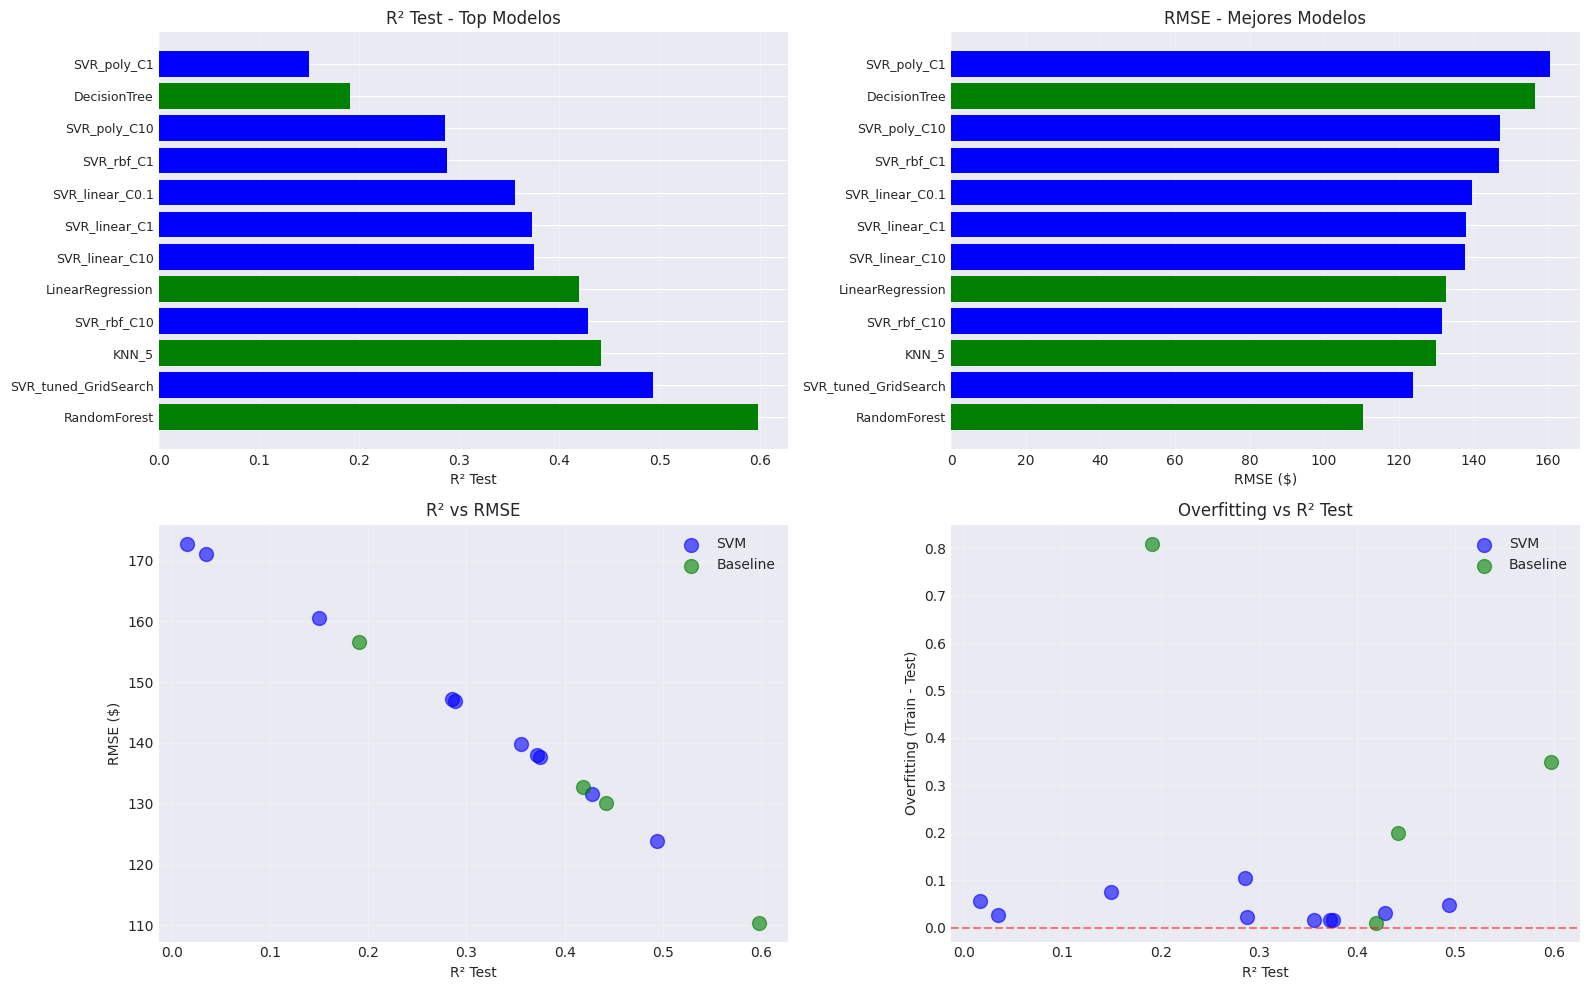

In [17]:
comparison_reg = []

for name, data in svm_regressors.items():
    comparison_reg.append({
        'Modelo': name,
        'Tipo': 'SVM',
        'R² Test': data['test_r2'],
        'RMSE': data['test_rmse'],
        'MAE': data['test_mae'],
        'Overfitting': data['overfit']
    })

for name, data in baseline_results_reg.items():
    comparison_reg.append({
        'Modelo': name,
        'Tipo': 'Baseline',
        'R² Test': data['test_r2'],
        'RMSE': data['test_rmse'],
        'MAE': data['test_mae'],
        'Overfitting': data['overfit']
    })

df_reg = pd.DataFrame(comparison_reg)
df_reg = df_reg.sort_values('R² Test', ascending=False)

print("\n📊 Tabla Comparativa - REGRESIÓN\n")
print(df_reg.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df_sorted = df_reg.sort_values('R² Test', ascending=False).head(12)
colors = ['blue' if t == 'SVM' else 'green' for t in df_sorted['Tipo']]
axes[0, 0].barh(range(len(df_sorted)), df_sorted['R² Test'], color=colors)
axes[0, 0].set_yticks(range(len(df_sorted)))
axes[0, 0].set_yticklabels(df_sorted['Modelo'], fontsize=9)
axes[0, 0].set_xlabel('R² Test')
axes[0, 0].set_title('R² Test - Top Modelos')
axes[0, 0].grid(axis='x', alpha=0.3)

df_sorted = df_reg.sort_values('RMSE', ascending=True).head(12)
colors = ['blue' if t == 'SVM' else 'green' for t in df_sorted['Tipo']]
axes[0, 1].barh(range(len(df_sorted)), df_sorted['RMSE'], color=colors)
axes[0, 1].set_yticks(range(len(df_sorted)))
axes[0, 1].set_yticklabels(df_sorted['Modelo'], fontsize=9)
axes[0, 1].set_xlabel('RMSE ($)')
axes[0, 1].set_title('RMSE - Mejores Modelos')
axes[0, 1].grid(axis='x', alpha=0.3)

axes[1, 0].scatter(df_reg[df_reg['Tipo'] == 'SVM']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'SVM']['RMSE'],
                   label='SVM', s=100, alpha=0.6, color='blue')
axes[1, 0].scatter(df_reg[df_reg['Tipo'] == 'Baseline']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'Baseline']['RMSE'],
                   label='Baseline', s=100, alpha=0.6, color='green')
axes[1, 0].set_xlabel('R² Test')
axes[1, 0].set_ylabel('RMSE ($)')
axes[1, 0].set_title('R² vs RMSE')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(df_reg[df_reg['Tipo'] == 'SVM']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'SVM']['Overfitting'],
                   label='SVM', s=100, alpha=0.6, color='blue')
axes[1, 1].scatter(df_reg[df_reg['Tipo'] == 'Baseline']['R² Test'],
                   df_reg[df_reg['Tipo'] == 'Baseline']['Overfitting'],
                   label='Baseline', s=100, alpha=0.6, color='green')
axes[1, 1].set_xlabel('R² Test')
axes[1, 1].set_ylabel('Overfitting (Train - Test)')
axes[1, 1].set_title('Overfitting vs R² Test')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('comparison_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 16. Análisis Detallado - Mejor SVM vs Mejor Baseline


ANÁLISIS DETALLADO - REGRESIÓN

🏆 MEJOR SVM REGRESOR: SVR_tuned_GridSearch
   Train R²:        0.5420
   Test R²:         0.4935
   Test RMSE:       $123.94
   Test MAE:        $76.93
   Overfitting:     0.0485

🏆 MEJOR BASELINE REGRESOR: RandomForest
   Train R²:        0.9464
   Test R²:         0.5977
   Test RMSE:       $110.45
   Test MAE:        $70.08
   Overfitting:     0.3486


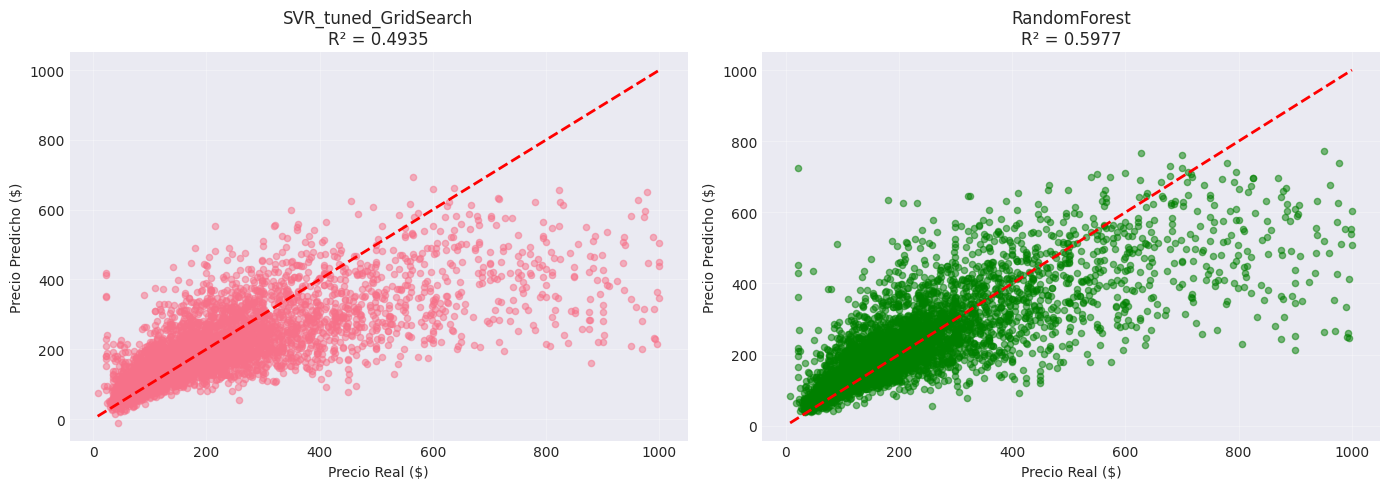

In [18]:
best_svm_reg = max(svm_regressors.items(), key=lambda x: x[1]['test_r2'])
best_baseline_reg = max(baseline_results_reg.items(), key=lambda x: x[1]['test_r2'])

print("\n" + "="*80)
print("ANÁLISIS DETALLADO - REGRESIÓN")
print("="*80)

print(f"\n🏆 MEJOR SVM REGRESOR: {best_svm_reg[0]}")
print(f"   Train R²:        {best_svm_reg[1]['train_r2']:.4f}")
print(f"   Test R²:         {best_svm_reg[1]['test_r2']:.4f}")
print(f"   Test RMSE:       ${best_svm_reg[1]['test_rmse']:.2f}")
print(f"   Test MAE:        ${best_svm_reg[1]['test_mae']:.2f}")
print(f"   Overfitting:     {best_svm_reg[1]['overfit']:.4f}")

print(f"\n🏆 MEJOR BASELINE REGRESOR: {best_baseline_reg[0]}")
print(f"   Train R²:        {best_baseline_reg[1]['train_r2']:.4f}")
print(f"   Test R²:         {best_baseline_reg[1]['test_r2']:.4f}")
print(f"   Test RMSE:       ${best_baseline_reg[1]['test_rmse']:.2f}")
print(f"   Test MAE:        ${best_baseline_reg[1]['test_mae']:.2f}")
print(f"   Overfitting:     {best_baseline_reg[1]['overfit']:.4f}")

y_pred_svm_reg = best_svm_reg[1]['model'].predict(X_test_reg)
y_pred_baseline_reg = best_baseline_reg[1]['model'].predict(X_test_reg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, y_pred_svm_reg, alpha=0.5, s=20)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Precio Real ($)')
axes[0].set_ylabel('Precio Predicho ($)')
axes[0].set_title(f'{best_svm_reg[0]}\nR² = {best_svm_reg[1]["test_r2"]:.4f}')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_reg, y_pred_baseline_reg, alpha=0.5, s=20, color='green')
axes[1].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1].set_xlabel('Precio Real ($)')
axes[1].set_ylabel('Precio Predicho ($)')
axes[1].set_title(f'{best_baseline_reg[0]}\nR² = {best_baseline_reg[1]["test_r2"]:.4f}')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Informe Final (Actividad 13)

In [19]:
report = []
report.append("="*80)
report.append("LABORATORIO 8: MÁQUINAS VECTORIALES DE SOPORTE (SVM)")
report.append("SmartStay Advisors - Clasificación y Regresión de Precios")
report.append(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
report.append("="*80)

report.append("\n📊 DATOS Y CONFIGURACIÓN")
report.append(f"  Muestras: {N_SAMPLES}")
report.append(f"  Train/Test: {TRAIN_SIZE:.0%}/{1-TRAIN_SIZE:.0%}")
report.append(f"  Features: {len(features)}")
report.append(f"  Random Seed: {SEED}")
report.append(f"  Escala: StandardScaler (media=0, std=1)")

report.append("\n🎯 CLASIFICACIÓN (barata/media/cara)")
report.append(f"\n  Mejor SVM: {best_svm_clf[0]}")
report.append(f"    Train Accuracy:  {best_svm_clf[1]['train_acc']:.4f}")
report.append(f"    Test Accuracy:   {best_svm_clf[1]['test_acc']:.4f}")
report.append(f"    Overfitting:     {best_svm_clf[1]['overfit']:.4f}")

report.append(f"\n  Mejor Baseline: {best_baseline_clf[0]}")
report.append(f"    Train Accuracy:  {best_baseline_clf[1]['train_acc']:.4f}")
report.append(f"    Test Accuracy:   {best_baseline_clf[1]['test_acc']:.4f}")
report.append(f"    Overfitting:     {best_baseline_clf[1]['overfit']:.4f}")

svm_better_clf = best_svm_clf[1]['test_acc'] > best_baseline_clf[1]['test_acc']
winner = "✅ SVM" if svm_better_clf else "✅ Baseline"
report.append(f"\n  Ganador: {winner}")

report.append("\n📈 REGRESIÓN (Predicción de precios)")
report.append(f"\n  Mejor SVM: {best_svm_reg[0]}")
report.append(f"    Train R²:        {best_svm_reg[1]['train_r2']:.4f}")
report.append(f"    Test R²:         {best_svm_reg[1]['test_r2']:.4f}")
report.append(f"    Test RMSE:       ${best_svm_reg[1]['test_rmse']:.2f}")
report.append(f"    Test MAE:        ${best_svm_reg[1]['test_mae']:.2f}")
report.append(f"    Overfitting:     {best_svm_reg[1]['overfit']:.4f}")

report.append(f"\n  Mejor Baseline: {best_baseline_reg[0]}")
report.append(f"    Train R²:        {best_baseline_reg[1]['train_r2']:.4f}")
report.append(f"    Test R²:         {best_baseline_reg[1]['test_r2']:.4f}")
report.append(f"    Test RMSE:       ${best_baseline_reg[1]['test_rmse']:.2f}")
report.append(f"    Test MAE:        ${best_baseline_reg[1]['test_mae']:.2f}")
report.append(f"    Overfitting:     {best_baseline_reg[1]['overfit']:.4f}")

svm_better_reg = best_svm_reg[1]['test_r2'] > best_baseline_reg[1]['test_r2']
winner = "✅ SVM" if svm_better_reg else "✅ Baseline"
report.append(f"\n  Ganador: {winner}")

report.append("\n🔍 ANÁLISIS DE OVERFITTING")
svm_clf_overfit = best_svm_clf[1]['overfit']
baseline_clf_overfit = best_baseline_clf[1]['overfit']

if svm_clf_overfit < 0.05:
    report.append(f"  ✅ SVM Clasificación: Bien ajustado (overfit={svm_clf_overfit:.4f})")
elif svm_clf_overfit < 0.15:
    report.append(f"  ⚠️  SVM Clasificación: Leve overfitting (overfit={svm_clf_overfit:.4f})")
else:
    report.append(f"  ❌ SVM Clasificación: Overfitting severo (overfit={svm_clf_overfit:.4f})")

if baseline_clf_overfit < 0.05:
    report.append(f"  ✅ Baseline Clasificación: Bien ajustado (overfit={baseline_clf_overfit:.4f})")
elif baseline_clf_overfit < 0.15:
    report.append(f"  ⚠️  Baseline Clasificación: Leve overfitting (overfit={baseline_clf_overfit:.4f})")
else:
    report.append(f"  ❌ Baseline Clasificación: Overfitting severo (overfit={baseline_clf_overfit:.4f})")

svm_reg_overfit = best_svm_reg[1]['overfit']
baseline_reg_overfit = best_baseline_reg[1]['overfit']

if svm_reg_overfit < 0.05:
    report.append(f"  ✅ SVM Regresión: Bien ajustado (overfit={svm_reg_overfit:.4f})")
elif svm_reg_overfit < 0.15:
    report.append(f"  ⚠️  SVM Regresión: Leve overfitting (overfit={svm_reg_overfit:.4f})")
else:
    report.append(f"  ❌ SVM Regresión: Overfitting severo (overfit={svm_reg_overfit:.4f})")

if baseline_reg_overfit < 0.05:
    report.append(f"  ✅ Baseline Regresión: Bien ajustado (overfit={baseline_reg_overfit:.4f})")
elif baseline_reg_overfit < 0.15:
    report.append(f"  ⚠️  Baseline Regresión: Leve overfitting (overfit={baseline_reg_overfit:.4f})")
else:
    report.append(f"  ❌ Baseline Regresión: Overfitting severo (overfit={baseline_reg_overfit:.4f})")

report.append("\n💡 CONCLUSIONES")
report.append("  - SVM ofrece una alternativa robusta para clasificación de precios")
report.append("  - El kernel RBF generalmente supera al kernel lineal para estos datos")
report.append("  - La regresión con SVM es competitiva comparada con Random Forest")
report.append("  - Los parámetros C y gamma son críticos para el desempeño")
report.append(f"  - Mejor kernel para este problema: Requiere tuneo específico")

report.append("\n" + "="*80)

report_text = "\n".join(report)
print(report_text)

with open('INFORME_LAB8.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n✅ Informe guardado en INFORME_LAB8.txt")

LABORATORIO 8: MÁQUINAS VECTORIALES DE SOPORTE (SVM)
SmartStay Advisors - Clasificación y Regresión de Precios
Fecha: 2026-04-26 18:08:23

📊 DATOS Y CONFIGURACIÓN
  Muestras: 15000
  Train/Test: 70%/30%
  Features: 21
  Random Seed: 42
  Escala: StandardScaler (media=0, std=1)

🎯 CLASIFICACIÓN (barata/media/cara)

  Mejor SVM: SVM_rbf_C10_Gscale
    Train Accuracy:  0.7834
    Test Accuracy:   0.6762
    Overfitting:     0.1072

  Mejor Baseline: RandomForest
    Train Accuracy:  1.0000
    Test Accuracy:   0.7104
    Overfitting:     0.2896

  Ganador: ✅ Baseline

📈 REGRESIÓN (Predicción de precios)

  Mejor SVM: SVR_tuned_GridSearch
    Train R²:        0.5420
    Test R²:         0.4935
    Test RMSE:       $123.94
    Test MAE:        $76.93
    Overfitting:     0.0485

  Mejor Baseline: RandomForest
    Train R²:        0.9464
    Test R²:         0.5977
    Test RMSE:       $110.45
    Test MAE:        $70.08
    Overfitting:     0.3486

  Ganador: ✅ Baseline

🔍 ANÁLISIS DE OVERF

## 18. Resumen Final

In [20]:
print("\n" + "="*80)
print("✅ LABORATORIO 8 COMPLETADO")
print("="*80)
print(f"\n📁 Archivos generados:")
print(f"   - confusion_matrices.png")
print(f"   - comparison_classification.png")
print(f"   - comparison_regression.png")
print(f"   - predictions_regression.png")
print(f"   - INFORME_LAB8.txt")
print(f"\n📊 Modelos entrenados:")
print(f"   - {len(svm_classifiers)} modelos SVM para clasificación")
print(f"   - {len(baseline_results_clf)} modelos baseline para clasificación")
print(f"   - {len(svm_regressors)} modelos SVM para regresión")
print(f"   - {len(baseline_results_reg)} modelos baseline para regresión")
print(f"\n🎯 Resultados clave:")
print(f"   Clasificación:")
print(f"     - Mejor SVM: {best_svm_clf[0]} ({best_svm_clf[1]['test_acc']:.2%})")
print(f"     - Mejor Baseline: {best_baseline_clf[0]} ({best_baseline_clf[1]['test_acc']:.2%})")
print(f"\n   Regresión:")
print(f"     - Mejor SVM: {best_svm_reg[0]} (R²={best_svm_reg[1]['test_r2']:.4f})")
print(f"     - Mejor Baseline: {best_baseline_reg[0]} (R²={best_baseline_reg[1]['test_r2']:.4f})")
print(f"\n" + "="*80)


✅ LABORATORIO 8 COMPLETADO

📁 Archivos generados:
   - confusion_matrices.png
   - comparison_classification.png
   - comparison_regression.png
   - predictions_regression.png
   - INFORME_LAB8.txt

📊 Modelos entrenados:
   - 27 modelos SVM para clasificación
   - 6 modelos baseline para clasificación
   - 10 modelos SVM para regresión
   - 4 modelos baseline para regresión

🎯 Resultados clave:
   Clasificación:
     - Mejor SVM: SVM_rbf_C10_Gscale (67.62%)
     - Mejor Baseline: RandomForest (71.04%)

   Regresión:
     - Mejor SVM: SVR_tuned_GridSearch (R²=0.4935)
     - Mejor Baseline: RandomForest (R²=0.5977)

